# policy approximation - REINFORCE algorithm
- It is a simplest policy gradient algorithm.
- It directly updates policy using full episode returns (Monte Carlo), without bootstrapping.
- Policy gradient by Monte Carlo. 

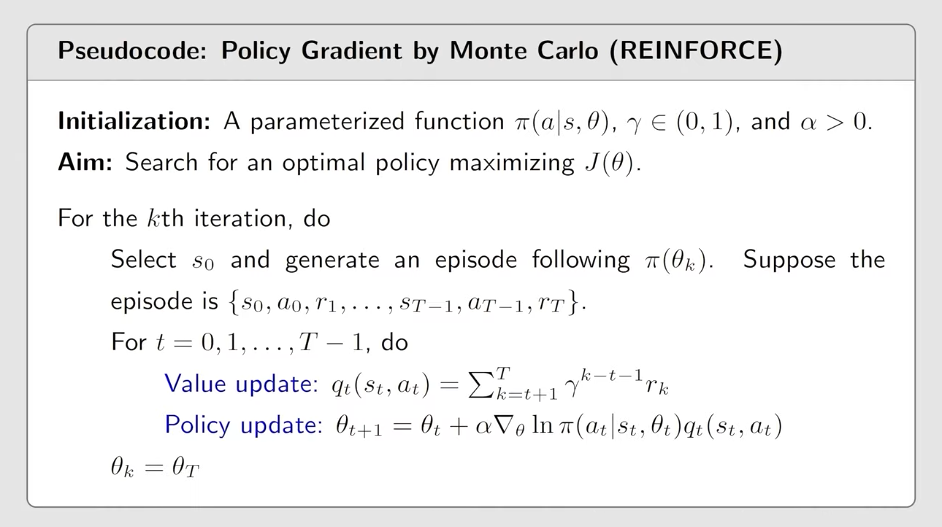

## Implementation

In [1]:
import random
import math
import torch
from torch import nn 
from torch import optim
from collections import deque

from frozen_lake_environment import (generate_grid_randomly,
                                     FrozenLakeEnvironment,
                                     State)
import numpy as np
from matplotlib import pyplot
from visual_utils import (render_policy_and_value, 
                          animate_policy_value_video,
                          plot_trajectory_history)

In [20]:
class PNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.ffn = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim),
            nn.Softmax(dim=-1)
        )
    def forward(self, state):
        return self.ffn(state)

In [21]:
def random_choice(values, probs):
    r = random.random()
    cumulative = 0.0
    for i in range(len(probs)):
        p = probs[i]
        cumulative += p.item()
        if r <= cumulative:
            return values[i], probs[i]
    return values[-1], probs[-1]  # fallback for floating point edge case


def soft_policy(p_net, state_feat_vec, env):    
    state_feat_vec = torch.FloatTensor(state_feat_vec).unsqueeze(0) # 1 X state_dim
    action_probs = p_net(state_feat_vec).squeeze(0)  # 1 X n_actions
    action, action_prob = random_choice(env.all_action_idx,
                                        action_probs)
    
    return action, action_prob

def get_policy_table(p_net, env):
    states = [State(s_idx, env.n_cols) for s_idx in range(env.n_states)]
    policy = np.zeros(env.n_states, dtype=np.int8)

    for state in states:
        state_feat_vec = state.get_state_feature_vec(env.n_states)
        state_feat_vec = torch.Tensor(state_feat_vec).unsqueeze(0) # 1 X feat_vec
        with torch.no_grad():
            action_probs = p_net(state_feat_vec).squeeze(0)
            policy[state.idx] = torch.argmax(action_probs).item()
    return policy

In [22]:
def run_episode(env, p_net, state, max_step=10000, episode_idx=0):
    """
    verbose : 
      - 0 : None 
      - 1 : CLI
      - 2 : GUI  
    """
    
    trajectory = []

    # --- initial action -----
    state_feature_vec = state.get_state_feature_vec(env.n_states)    
    action, action_prob = soft_policy(p_net,
                                      state_feature_vec,
                                      env)
    
    for step in range(max_step):
        result = env.step(state, action)
        reward = result["reward"]
        trajectory.append((state, action, action_prob, reward))
        
        next_state = result["new_state"]
        is_terminated = result["is_terminated"]

        if is_terminated:
            break
        
        state_feature_vec = next_state.get_state_feature_vec(env.n_states)
        next_action, next_action_prob = soft_policy(p_net,
                                                    state_feature_vec,
                                                    env)

        state = next_state
        action = next_action
        action_prob = next_action_prob

    return trajectory

In [48]:
def run_reinforce_learning(env, n_episodes=500, gamma=0.99, lr=0.001):
    policy_histories = []
    Q_histories = []
    trajectory_histories = []
  
    p_net = PNetwork(env.n_states,
                     env.n_actions)  
    optimizer = optim.Adam(p_net.parameters(),
                           lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer,
                                                     T_max=n_episodes,
                                                     eta_min=0.00001)

    rewards = []
    for episode_idx in range(n_episodes):
        # --- initial state -----
        state = env.find('S')
        # -----------------------------------        
        episode_reward = 0
        
        trajectory = run_episode(env,
                                 p_net,
                                 state)
        
        Q = np.zeros((env.n_states, env.n_actions), dtype=np.float32)

        G = 0
        
        losses = []
        for transition_step in reversed(trajectory):
            s, a, a_prob, r = transition_step

            # ----- value update --------
            G = r + gamma * G
            Q[s.idx][a] = G
 
            # ----- loss calculation ----
            loss = -torch.log(a_prob) * Q[s.idx][a]
            
            losses.append(loss)
            episode_reward += r
        
        # ---- single policy update -----
        optimizer.zero_grad()
        total_loss = torch.stack(losses).sum()
        
        total_loss.backward()
        optimizer.step()
        scheduler.step()
        
        rewards.append(episode_reward)
        trajectory_histories.append([traj[0].coord for traj in trajectory])
        
        if episode_idx % 500 == 0:
            avg = np.mean(rewards[-100:])
            # print(f"Episode {episode_idx} | Avg Reward: {avg:.3f} | total loss: {total_loss}")
            policy = get_policy_table(p_net, env)
            # print("policy: ", policy)
            
            policy_histories.append(policy)
            Q_histories.append(Q)
            
    return policy_histories, Q_histories, trajectory_histories

In [49]:
lake_grid = [["G", "F", "F", "F"],
             ["F", "F", "F", "F"],
             ["F", "F", "H", "F"],
             ["F", "H", "S", "F"]]
# lake_grid = [["F", "F", "S", "F", "H"],
#              ["F", "F", "H", "F", "F"],
#              ["F", "F", "F", "G", "F"],
#              ["F", "H", "F", "F", "F"],
#              ["H", "H", "F", "F", "F"]]

reward_points = {
    "S": 0,
    "G": 10,
    "F": 0,
    "H": 0
}

frozen_lake = FrozenLakeEnvironment(grid=lake_grid,
                                    reward_points=reward_points,
                                    slippery=True)

In [50]:
policy_histories, q_histories, trajectory_histories = run_reinforce_learning(frozen_lake, n_episodes=20000)

In [51]:
policy = policy_histories[-1]
q_table = q_histories[-1]

In [52]:
# trajectory_histories

In [53]:
q_histories[-1]

array([[ 0.      ,  0.      ,  0.      ,  0.      ],
       [10.      ,  0.      ,  0.      ,  9.9     ],
       [ 9.801   ,  0.      ,  0.      ,  0.      ],
       [ 9.60596 ,  0.      ,  0.      ,  0.      ],
       [ 0.      ,  0.      ,  0.      ,  0.      ],
       [ 0.      ,  0.      ,  0.      ,  0.      ],
       [ 0.      ,  0.      ,  0.      ,  0.      ],
       [ 0.      ,  0.      ,  0.      ,  9.5099  ],
       [ 0.      ,  0.      ,  0.      ,  0.      ],
       [ 0.      ,  0.      ,  0.      ,  0.      ],
       [ 0.      ,  0.      ,  0.      ,  0.      ],
       [ 0.      ,  0.      ,  0.      ,  9.320654],
       [ 0.      ,  0.      ,  0.      ,  0.      ],
       [ 0.      ,  0.      ,  0.      ,  0.      ],
       [ 0.      ,  0.      ,  9.135173,  0.      ],
       [ 0.      ,  0.      ,  0.      ,  9.227447]], dtype=float32)

# Render policy

In [54]:
import pandas as pd
from IPython.display import display

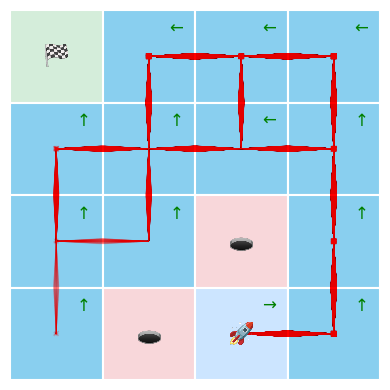

In [55]:
plot_trajectory_history(frozen_lake, trajectory_histories, policy)